# Загрузка изображения и представление его матрицей

In [ ]:
import cv2
import numpy as np

image_path = r"picture1.png"  #никакой кириллицы тут в пути!!!
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError('Изображение не грузанулось')

img = cv2.resize(img, (256, 256))

print(img)
print('')
print(img.shape)
print(img.dtype)
print('')

imgf = img.astype(np.float64)
print(imgf)

[[ 58  61  61 ... 124 124 124]
 [ 58  60  61 ... 124 125 124]
 [ 60  60  61 ... 125 125 124]
 ...
 [ 97  96  94 ...  68  71  87]
 [170 170 169 ...  68  72  85]
 [216 217 216 ...  67  72  75]]

(256, 256)
uint8

[[ 58.  61.  61. ... 124. 124. 124.]
 [ 58.  60.  61. ... 124. 125. 124.]
 [ 60.  60.  61. ... 125. 125. 124.]
 ...
 [ 97.  96.  94. ...  68.  71.  87.]
 [170. 170. 169. ...  68.  72.  85.]
 [216. 217. 216. ...  67.  72.  75.]]


Оригинальное изображение


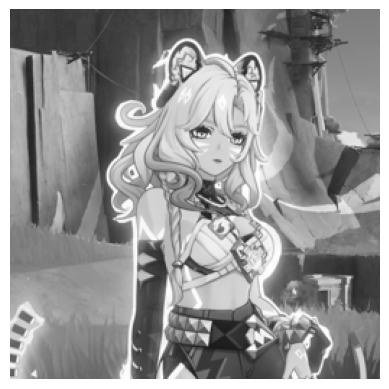

In [6]:
import matplotlib.pyplot as plt
def show_matrix_as_image(matrix):
    plt.imshow(matrix, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()
print("Оригинальное изображение")
show_matrix_as_image(img)

### Количество коэффициентов для обратного преобразования

In [2]:
#M = 16
#M = 32
M = 64
#M = 80
#M = 100

# Адамар

### Создание матрицы и преобразование изображения

**База:**  
$$
H_1 = \begin{bmatrix} 1 \end{bmatrix}
$$

**Рекурсивное правило:**  
$$
H_{2n} = \begin{bmatrix}
H_n & H_n \\
H_n & -H_n
\end{bmatrix}
$$


In [3]:
def hadamard_matrix(n):      #n - это СТЕПЕНЬ 2!
    if n == 1:
        return np.array([[1]])
    Hn = hadamard_matrix(n // 2)
    top = np.hstack((Hn, Hn))   #как конкатенация, только двух матриц одинаковой размерности
    bottom = np.hstack((Hn, -Hn))  #типа к матрице сбоку приписываем ещё одну матрицу
    return np.vstack((top, bottom))  #аналогичное только матрице приписываем матрицу снизу



HadaM = hadamard_matrix(256)
res_hada = HadaM @ img @ HadaM.T
print(res_hada)

[[9016100    2726   -8300 ...    4368   15898    8580]
 [  -5260    -346     692 ...     132    1062     512]
 [ -23112     102   -4276 ...    -100   -5490     580]
 ...
 [   7360   -2258    3524 ...    -364    1574   -2036]
 [  17972   -2634    6676 ...   -1652   -2738      56]
 [  -2328    1850   -3800 ...     724     174    1784]]


### Обратное преобразование

[[119 116 119 ... 122 121 124]
 [123 116 123 ... 121 126 129]
 [127 118 118 ... 125 127 122]
 ...
 [131 135 139 ... 141 139 126]
 [141 138 138 ... 142 138 136]
 [147 136 133 ... 138 136 140]]


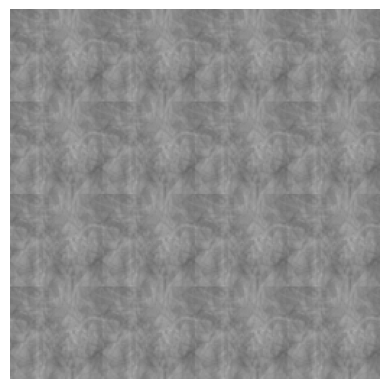

In [7]:
cut = np.zeros_like(res_hada)
cut[:M, :M] = res_hada[:M, :M]

# Обратное преобразование
H = hadamard_matrix(256)   #256 - высота изображения
img_back_had = (H.T @ cut @ H) / (img.shape[0] ** 2)

# Приводим к виду для отображения
img_back_had = np.clip(img_back_had, 0, 255).astype(np.uint8)
print(img_back_had)
show_matrix_as_image(img_back_had)


### Средняя дисперсия ошибок

In [5]:
disp_had = 0
img_back_had = img_back_had.astype(np.float64)
for i in range(0, 256):
    for j in range(0, 256):
        disp_had = disp_had + ((imgf[i][j] - img_back_had[i][j]) / 256) ** 2

print(disp_had)

2820.095703125


# ДКП - Дискретное косинусное преобразование

### Создание матрицы и преобразование изображения

Формула элементов матрицы:
$$
D_{k,n} = \alpha(k) \cdot \cos\left[ \frac{\pi}{N} \left( n + \frac{1}{2} \right) k \right]
$$

Где коэффициент нормализации $\alpha(k)$ определяется как:
$$
\alpha(k) = 
\begin{cases}
\sqrt{\frac{1}{N}}, & \text{если } k = 0 \\
\sqrt{\frac{2}{N}}, & \text{если } k > 0
\end{cases}
$$

In [9]:
def dct_matrix(n):
    D = np.zeros((n, n))
    for p in range(n):
        for q in range(n):
            if p == 0:
                alpha = np.sqrt(1/n)
            else:
                alpha = np.sqrt(2/n)
            D[p, q] = alpha * np.cos(np.pi * (q + 0.5) * p / n)
    return D


dctM = dct_matrix(256)
res_dct = dctM @ imgf @ dctM.T
print(res_dct)

[[ 3.52191406e+04 -5.58506214e+01 -2.59919288e+03 ...  2.56231034e+00
  -1.46610072e+01 -2.09412548e+00]
 [-1.18926892e+03 -1.72597162e+03 -1.35603464e+03 ...  5.38285074e+00
   1.95688257e-01  5.48834971e+00]
 [-4.20589952e+03  1.50886127e+02  2.66762166e+03 ...  1.42151286e+01
  -3.83931682e+00 -8.81695051e+00]
 ...
 [ 6.15981215e+00  2.29482671e-01  1.67789096e+00 ... -5.73659937e-01
   1.98617066e-02 -1.18879190e+00]
 [ 1.40628722e+01 -1.24286935e+01 -4.59804441e+00 ...  6.70907761e+00
  -1.90004043e+00 -1.66341510e+00]
 [-3.96297088e+00 -7.13537778e+00  1.30669769e+01 ...  5.01816782e-01
   2.99236482e+00 -6.57087762e-01]]


### Обратное преобразование

[[ 59  58  58 ... 124 122 122]
 [ 59  59  59 ... 124 123 123]
 [ 60  60  60 ... 124 124 124]
 ...
 [124 134 153 ...  72  80  85]
 [168 174 184 ...  70  79  85]
 [197 200 204 ...  68  79  85]]


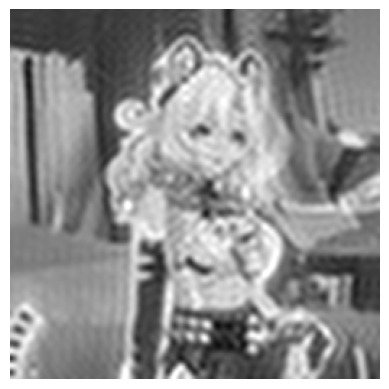

In [10]:
from scipy.fftpack import idct

cut = np.zeros_like(res_dct)
cut[:M, :M] = res_dct[:M, :M]

img_back_dct = idct(idct(cut.T, norm='ortho').T, norm='ortho')
img_back_dct = np.clip(img_back_dct, 0, 255).astype(np.uint8)
print(img_back_dct)
show_matrix_as_image(img_back_dct)


### Средняя дисперсия ошибок

In [ ]:
disp_dct = 0
img_back_dct = img_back_dct.astype(np.float64)
for i in range(0, 256):
    for j in range(0, 256):
        disp_dct = disp_dct + ((imgf[i][j] - img_back_dct[i][j]) / 256) ** 2

print(disp_dct)

322.82814025878906


# ПКЛ - преобразованием Кархунена — Лоэва

### Создание матрицы и преобразование изображения

In [11]:
# 1. Центрирование (по строкам)
X = img - np.mean(img, axis=0)

# 2. Ковариационная матрица
cov = np.cov(X, rowvar=False)

# 3. Собственные значения и векторы
eig_vals, eig_vecs = np.linalg.eigh(cov)

# 4. Сортировка по убыванию
idx = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, idx]

# 5. Оставляем первые k компонент (например, 64)
k = 64
W = eig_vecs[:, :k]

# 6. Преобразование PCA
res_pca = X @ W
print(res_pca)


[[-8.15432149e+02 -4.81557847e+02  4.13766911e+01 ...  2.89263055e+00
  -1.73232856e+01  2.63820582e+01]
 [-8.18995309e+02 -4.90500917e+02  4.54054628e+01 ... -3.94688813e+00
  -2.70593062e+01  4.26062794e+00]
 [-8.16740418e+02 -4.99366120e+02  4.08579786e+01 ...  5.74702307e+00
  -2.85127846e+01  1.69620742e+00]
 ...
 [-5.04594334e+02  4.50790546e+02 -9.59442826e+01 ... -1.31305066e+01
  -1.62333756e-01  1.58072313e+01]
 [-4.70146559e+02  4.28406749e+02 -9.87541215e+01 ...  1.32539154e+00
  -6.41895929e+01  8.35060086e+00]
 [-4.41961487e+02  3.99159185e+02 -8.17387332e+01 ...  1.89646128e+01
  -7.06497381e+01  9.60777923e+00]]


### Обратное преобразование

[[ 59  60  63 ... 122 120 120]
 [ 61  60  59 ... 123 123 120]
 [ 65  66  62 ... 127 127 125]
 ...
 [108 106 106 ...  62  67  79]
 [168 168 163 ...  68  70  81]
 [208 210 205 ...  72  70  78]]
(256, 256)


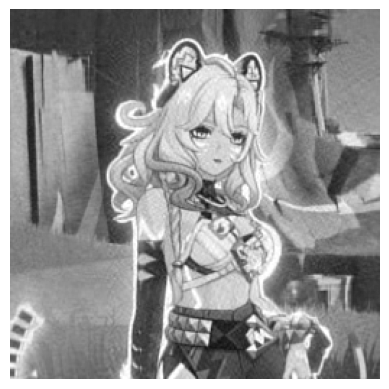

In [13]:
W_cut = W[:, :M]
res_pca_cut = X @ W_cut

# Обратное преобразование
img_back_pca = res_pca_cut @ W_cut.T + np.mean(img, axis=0)
img_back_pca = np.clip(img_back_pca, 0, 255).astype(np.uint8)
print(img_back_pca)
print(img_back_pca.shape)
show_matrix_as_image(img_back_pca)

### Средняя дисперсия ошибок

In [14]:
disp_pca = 0
img_back_pca = img_back_pca.astype(np.float64)
for i in range(0, 256):
    for j in range(0, 256):
        disp_pca = disp_pca + ((imgf[i][j] - img_back_pca[i][j]) / 256) ** 2

print(disp_pca)

45.85675048828125
